# Agent Outcome HPO

This notebook loads a NeuralSignal feature run, extracts an agent end-state label from a JSON column, maps those string outcomes to a binary target, saves the prepared dataset, then runs a small Optuna search over an XGBoost classifier.

In [1]:
# Parameters: edit this cell first.
from pathlib import Path

# Input run. Can point at a run directory under runs/ or directly at a parquet file.
RESULTS_PATH = Path("runs/remote/malt-full-normal-bs1")

# Activation feature selection. These must match feature column names in the parquet file.
SELECTED_FEATURES = [
    # "feature_set__feature_name",
]

# Columns and output names.
JSON_COLUMN = "metadata_json"
AGENT_OUTCOME_COLUMN = "agent_outcome"
TARGET_COLUMN = "target"
OUTPUT_DIR = Path("runs/notebook-agent-outcome-hpo")
PREPARED_DATASET_FILENAME = "agent_outcome_prepared.parquet"
PREDICTIONS_FILENAME = "agent_outcome_predictions.csv"
METRICS_FILENAME = "agent_outcome_metrics.json"

# Where to look inside JSON_COLUMN. Dotted paths are supported.
OUTCOME_KEY_CANDIDATES = [
    "agent_outcome",
    "agent_end_state",
    "end_state",
    "final_state",
    "outcome",
    "status",
    "result",
    "run_labels",
    "labels",
    "metadata.agent_outcome",
    "metadata.agent_end_state",
    "metadata.end_state",
    "metadata.run_labels",
]
SEARCH_JSON_RECURSIVELY = True
NORMALIZE_OUTCOME_TEXT = True

# Binary target mapping, modeled after the train CLI behavior.
# Positive outcomes become 1. Explicit negative outcomes become 0.
# UNMATCHED_OUTCOME can be "negative", "exclude", or "error".
POSITIVE_OUTCOMES = ["normal"]
NEGATIVE_OUTCOMES = []
UNMATCHED_OUTCOME = "negative"

# Model/evaluation settings.
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_OPTUNA_TRIALS = 8
PREDICTION_THRESHOLD = 0.5
OPTUNA_DIRECTION = "maximize"
OPTUNA_METRIC = "f1"

# XGBoost fixed settings. The HPO cell tunes a small set on top of these.
XGB_BASE_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "device": "cpu",
    "n_jobs": 4,
    "random_state": RANDOM_STATE,
}

# Display and plotting.
TOP_FEATURE_IMPORTANCE_COUNT = 25
FIGSIZE = (6, 5)
SAVE_FIGURES = True
AUC_FIGURE_FILENAME = "roc_curve.png"
CONFUSION_MATRIX_FIGURE_FILENAME = "confusion_matrix.png"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [2]:
import json
import math
from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

try:
    import optuna
except ImportError as exc:
    raise ImportError("Install optuna before running HPO: uv pip install optuna") from exc

plt.style.use("default")

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers

In [3]:
def read_feature_run(path: Path) -> pd.DataFrame:
    path = Path(path)
    if path.is_file():
        return pd.read_parquet(path)

    manifest_path = path / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if manifest.get("state", "completed") != "completed":
            raise ValueError(f"Feature run is not completed: {path}")
        parquet_paths = [path / shard["path"] for shard in manifest.get("shards", [])]
    else:
        parquet_paths = sorted((path / "features").rglob("*.parquet"))
        if not parquet_paths:
            parquet_paths = sorted(path.glob("*.parquet"))

    if not parquet_paths:
        raise FileNotFoundError(f"No parquet files found under {path}")
    return pd.concat([pd.read_parquet(item) for item in parquet_paths], ignore_index=True)


def parse_json_value(value):
    if isinstance(value, Mapping):
        return dict(value)
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return json.loads(value) if value.strip() else {}
    if pd.isna(value):
        return {}
    return value


def get_dotted_value(row, dotted_key):
    current = row
    for part in dotted_key.split("."):
        if not isinstance(current, Mapping) or part not in current:
            return None
        current = current[part]
    return current


def recursive_find(row, key_names):
    if isinstance(row, Mapping):
        for key, value in row.items():
            if key in key_names:
                return value
            found = recursive_find(value, key_names)
            if found is not None:
                return found
    elif isinstance(row, list):
        for value in row:
            found = recursive_find(value, key_names)
            if found is not None:
                return found
    return None


def normalize_outcome(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    if isinstance(value, Mapping):
        return json.dumps(value, sort_keys=True)
    if isinstance(value, list):
        if len(value) == 1:
            return normalize_outcome(value[0])
        return ",".join(str(item) for item in value)
    text = str(value).strip()
    return text.lower() if NORMALIZE_OUTCOME_TEXT else text


def extract_agent_outcome(json_value):
    row = parse_json_value(json_value)
    for key in OUTCOME_KEY_CANDIDATES:
        value = get_dotted_value(row, key)
        if value is not None:
            return normalize_outcome(value)
    if SEARCH_JSON_RECURSIVELY:
        key_names = {key.split(".")[-1] for key in OUTCOME_KEY_CANDIDATES}
        return normalize_outcome(recursive_find(row, key_names))
    return None


def encode_binary_target(outcomes: pd.Series) -> pd.Series:
    if UNMATCHED_OUTCOME not in {"negative", "exclude", "error"}:
        raise ValueError('UNMATCHED_OUTCOME must be "negative", "exclude", or "error"')

    positive = {normalize_outcome(item) for item in POSITIVE_OUTCOMES}
    negative = {normalize_outcome(item) for item in NEGATIVE_OUTCOMES}
    overlap = positive & negative
    if overlap:
        raise ValueError(f"Positive and negative outcomes overlap: {sorted(overlap)}")

    encoded = []
    for value in outcomes:
        if pd.isna(value):
            encoded.append(np.nan)
        elif value in positive:
            encoded.append(1)
        elif value in negative or UNMATCHED_OUTCOME == "negative":
            encoded.append(0)
        elif UNMATCHED_OUTCOME == "exclude":
            encoded.append(np.nan)
        else:
            raise ValueError(f"Unmapped outcome: {value!r}")
    return pd.Series(encoded, index=outcomes.index, dtype="float")


def classification_metrics(y_true, scores, threshold=PREDICTION_THRESHOLD):
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    ratio = lambda numerator, denominator: float(numerator / denominator) if denominator else float("nan")
    return {
        "auc": float(roc_auc_score(y_true, scores)) if len(set(y_true)) == 2 else float("nan"),
        "auprc": float(average_precision_score(y_true, scores)) if tp + fn else float("nan"),
        "accuracy": float(accuracy_score(y_true, preds)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, preds, zero_division=0)),
        "specificity": ratio(tn, tn + fp),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, preds)),
        "log_loss": float(log_loss(y_true, scores, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, scores)),
        "false_positive_rate": ratio(fp, tn + fp),
        "false_negative_rate": ratio(fn, tp + fn),
        "negative_predictive_value": ratio(tn, tn + fn),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def clean_json(value):
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, dict):
        return {key: clean_json(item) for key, item in value.items()}
    if isinstance(value, list):
        return [clean_json(item) for item in value]
    return value

In [4]:
# OVERRIDE_READ_FEATURE_RUN_RECURSIVE_FEATURES
# Run this cell if your open notebook still shows the older loader.
def resolve_results_path(path: Path) -> Path:
    path = Path(path).expanduser()
    if path.exists():
        return path
    if path.is_absolute():
        raise FileNotFoundError(f"RESULTS_PATH does not exist: {path}")

    candidates = [Path.cwd() / path, *[parent / path for parent in Path.cwd().parents]]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    tried = "\n".join(str(candidate) for candidate in candidates[:8])
    raise FileNotFoundError(f"RESULTS_PATH does not exist from this notebook session: {path}\nTried:\n{tried}")


def read_feature_run(path: Path) -> pd.DataFrame:
    path = resolve_results_path(path)
    print(f"Resolved RESULTS_PATH to: {path}")
    if path.is_file():
        return pd.read_parquet(path)

    manifest_path = path / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if manifest.get("state", "completed") != "completed":
            raise ValueError(f"Feature run is not completed: {path}")
        parquet_paths = [path / shard["path"] for shard in manifest.get("shards", [])]
        parquet_paths = [item for item in parquet_paths if item.exists()]
    else:
        parquet_paths = []

    if not parquet_paths:
        parquet_paths = sorted((path / "features").rglob("*.parquet"))
    if not parquet_paths:
        parquet_paths = sorted(path.rglob("*.parquet"))

    if not parquet_paths:
        raise FileNotFoundError(f"No parquet files found under {path / 'features'} or {path}")
    print(f"Found {len(parquet_paths):,} parquet file(s). First: {parquet_paths[0]}")
    return pd.concat([pd.read_parquet(item) for item in parquet_paths], ignore_index=True)


## Load And Prepare Data

In [5]:
raw = read_feature_run(RESULTS_PATH)
print(f"Loaded {len(raw):,} rows and {len(raw.columns):,} columns from {RESULTS_PATH}")

if JSON_COLUMN not in raw.columns:
    raise KeyError(f"JSON_COLUMN={JSON_COLUMN!r} is not present. Available columns include: {list(raw.columns[:20])}")
activation_features = [column for column in raw.columns if "__" in column]
if not SELECTED_FEATURES:
    SELECTED_FEATURES = activation_features
    print("SELECTED_FEATURES is empty; using all activation features.")

missing_features = [feature for feature in SELECTED_FEATURES if feature not in raw.columns]
if missing_features:
    raise KeyError(f"Selected features not found: {missing_features[:20]}")
if not SELECTED_FEATURES:
    raise ValueError("No activation feature columns found. Expected feature columns containing '__'.")

extra_activation_features = sorted(set(activation_features) - set(SELECTED_FEATURES))
print(f"Activation feature columns found: {len(activation_features):,}")
print(f"Selected activation features kept: {len(SELECTED_FEATURES):,}")
print(f"Activation features filtered out: {len(extra_activation_features):,}")

prepared = raw[[JSON_COLUMN, *SELECTED_FEATURES]].copy()
prepared[AGENT_OUTCOME_COLUMN] = raw[JSON_COLUMN].apply(extract_agent_outcome)

print("\nAgent outcome distribution before binary mapping:")
display(prepared[AGENT_OUTCOME_COLUMN].value_counts(dropna=False).rename_axis(AGENT_OUTCOME_COLUMN).to_frame("rows"))

Resolved RESULTS_PATH to: E:\Programming\neuralsignal\neuralsignal\runs\remote\malt-full-normal-bs1
Found 8 parquet file(s). First: E:\Programming\neuralsignal\neuralsignal\runs\remote\malt-full-normal-bs1\features\part-00000.parquet


Loaded 7,145 rows and 7,135 columns from runs\remote\malt-full-normal-bs1
SELECTED_FEATURES is empty; using all activation features.
Activation feature columns found: 7,128
Selected activation features kept: 7,128
Activation features filtered out: 0



Agent outcome distribution before binary mapping:


,rows
agent_outcome,
normal,6014
refusals,324
sabotage,224
reasoning_about_task,219
partial_problem_solving,165
match_weaker_model,121
ignores_task_instructions,24
bypass_constraints,16
hardcoded_solution,15


In [6]:
# LABEL_BREAKDOWN_NORMAL_VS_ALL_OTHER
label_breakdown = (
    prepared[AGENT_OUTCOME_COLUMN]
    .value_counts(dropna=False)
    .rename_axis(AGENT_OUTCOME_COLUMN)
    .reset_index(name="rows")
)
label_breakdown["target"] = np.where(label_breakdown[AGENT_OUTCOME_COLUMN] == "normal", 1, 0)
label_breakdown["percent"] = label_breakdown["rows"] / label_breakdown["rows"].sum()

print("Agent outcome label breakdown. Target convention: normal=1, all other labels=0.")
display(label_breakdown.style.format({"percent": "{:.2%}"}))

print("\nTarget totals:")
display(
    label_breakdown.groupby("target", as_index=True)["rows"]
    .sum()
    .rename_axis(TARGET_COLUMN)
    .to_frame("rows")
)


Agent outcome label breakdown. Target convention: normal=1, all other labels=0.


,agent_outcome,rows,target,percent
0,normal,6014,1,84.17%
1,refusals,324,0,4.53%
2,sabotage,224,0,3.14%
3,reasoning_about_task,219,0,3.07%
4,partial_problem_solving,165,0,2.31%
5,match_weaker_model,121,0,1.69%
6,ignores_task_instructions,24,0,0.34%
7,bypass_constraints,16,0,0.22%
8,hardcoded_solution,15,0,0.21%
9,gives_up,14,0,0.20%



Target totals:


,rows
target,
0,1131
1,6014


In [7]:
prepared[TARGET_COLUMN] = encode_binary_target(prepared[AGENT_OUTCOME_COLUMN])
excluded_rows = int(prepared[TARGET_COLUMN].isna().sum())
audit_prepared = prepared[prepared[TARGET_COLUMN].notna()].reset_index(drop=True)
audit_prepared[TARGET_COLUMN] = audit_prepared[TARGET_COLUMN].astype(int)

print(f"Excluded rows: {excluded_rows:,}")
print("\nBinary target distribution:")
display(audit_prepared[TARGET_COLUMN].value_counts(dropna=False).sort_index().rename_axis(TARGET_COLUMN).to_frame("rows"))

if audit_prepared[TARGET_COLUMN].nunique() != 2:
    raise ValueError("Binary target must contain both 0 and 1 after mapping.")
if min(audit_prepared[TARGET_COLUMN].value_counts()) < 2:
    raise ValueError("Each class needs at least two rows for stratified train/test splitting.")

prepared = audit_prepared[[*SELECTED_FEATURES, TARGET_COLUMN]].copy()
prepared_path = OUTPUT_DIR / PREPARED_DATASET_FILENAME
prepared.to_parquet(prepared_path, index=False)
print(f"Saved feature-only prepared dataset to {prepared_path.resolve()}")
print(f"Prepared shape: {prepared.shape[0]:,} rows x {prepared.shape[1]:,} columns")


Excluded rows: 0

Binary target distribution:


,rows
target,
0,1131
1,6014


Saved feature-only prepared dataset to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_prepared.parquet
Prepared shape: 7,145 rows x 7,129 columns


## Train/Test Split

In [8]:
x = prepared[SELECTED_FEATURES].astype(float)
y = prepared[TARGET_COLUMN].astype(int)

# Preserve the dataset's class ratio in both training and validation splits.
# Example: if the full dataset is 95% positive, each split should be about 95% positive.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_distribution = pd.DataFrame({
    "overall": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_test.value_counts(normalize=True).sort_index(),
}).fillna(0.0)

split_counts = pd.DataFrame({
    "overall": y.value_counts().sort_index(),
    "train": y_train.value_counts().sort_index(),
    "validation": y_test.value_counts().sort_index(),
}).fillna(0).astype(int)

print(f"Train rows: {len(x_train):,}; validation rows: {len(x_test):,}; features: {len(SELECTED_FEATURES):,}")
print("Class counts by split:")
display(split_counts)
print("Class ratios by split:")
display(split_distribution.style.format("{:.2%}"))


Train rows: 5,358; validation rows: 1,787; features: 7,128
Class counts by split:


,overall,train,validation
target,,,
0,1131,848,283
1,6014,4510,1504


Class ratios by split:


,overall,train,validation
target,,,
0,15.83%,15.83%,15.84%
1,84.17%,84.17%,84.16%


## Small Optuna HPO

In [9]:
def objective(trial):
    params = {
        **XGB_BASE_PARAMS,
        "n_estimators": trial.suggest_int("n_estimators", 75, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }
    model = XGBClassifier(**params)
    model.fit(x_train, y_train)
    scores = model.predict_proba(x_test)[:, 1]
    metrics = classification_metrics(y_test, scores)
    return metrics[OPTUNA_METRIC]


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction=OPTUNA_DIRECTION, sampler=sampler)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

print(f"Best {OPTUNA_METRIC}: {study.best_value:.4f}")
print("Best parameters:")
display(pd.Series(study.best_params).to_frame("value"))

trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
display(trials.sort_values("value", ascending=(OPTUNA_DIRECTION == "minimize")).head(10))

[I 2026-09-14 10:13:12,713] A new study created in memory with name: no-name-cb601493-1262-4384-bcf2-873533cb255c


[I 2026-09-14 10:13:56,942] Trial 0 finished with value: 0.9943727242634889 and parameters: {'n_estimators': 159, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2.403950683025824, 'reg_lambda': 0.13066739238053282}. Best is trial 0 with value: 0.9943727242634889.


[I 2026-09-14 10:14:45,280] Trial 1 finished with value: 0.9943727242634889 and parameters: {'n_estimators': 270, 'max_depth': 6, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 8.491983767203795, 'reg_lambda': 0.26587543983272705}. Best is trial 0 with value: 0.9943727242634889.


[I 2026-09-14 10:15:08,389] Trial 2 finished with value: 0.9937148527952365 and parameters: {'n_estimators': 116, 'max_depth': 3, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'min_child_weight': 3.6210622617823773, 'reg_lambda': 1.6738085788752133}. Best is trial 0 with value: 0.9943727242634889.


[I 2026-09-14 10:15:36,289] Trial 3 finished with value: 0.9943727242634889 and parameters: {'n_estimators': 106, 'max_depth': 4, 'learning_rate': 0.03476649150592621, 'subsample': 0.7824279936868144, 'colsample_bytree': 0.9140703845572055, 'min_child_weight': 2.7970640394252375, 'reg_lambda': 1.0677482709481354}. Best is trial 0 with value: 0.9943727242634889.


...

[I 2026-09-14 10:17:26,340] Trial 6 finished with value: 0.9927392739273927 and parameters: {'n_estimators': 82, 'max_depth': 8, 'learning_rate': 0.024112898115291985, 'subsample': 0.8650089137415928, 'colsample_bytree': 0.7246844304357644, 'min_child_weight': 5.680612190600297, 'reg_lambda': 1.2399967836846095}. Best is trial 0 with value: 0.9943727242634889.


[I 2026-09-14 10:17:58,120] Trial 7 finished with value: 0.9947019867549669 and parameters: {'n_estimators': 116, 'max_depth': 8, 'learning_rate': 0.13962563737015762, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595, 'min_child_weight': 6.381099809299767, 'reg_lambda': 6.978281265126034}. Best is trial 7 with value: 0.9947019867549669.


Best f1: 0.9947
Best parameters:


,value
n_estimators,116.000000
max_depth,8.000000
learning_rate,0.139626
subsample,0.975800
colsample_bytree,0.957931
min_child_weight,6.381100
reg_lambda,6.978281


,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_lambda,params_subsample,state
7,7,0.994702,0.957931,0.139626,8,6.381100,116,6.978281,0.975800,COMPLETE
0,0,0.994373,0.662407,0.120571,8,2.403951,159,0.130667,0.839463,COMPLETE
3,3,0.994373,0.914070,0.034766,4,2.797064,106,1.067748,0.782428,COMPLETE
1,1,0.994373,0.987964,0.111150,6,8.491984,270,0.265875,0.608234,COMPLETE
5,5,0.994373,0.776061,0.013940,4,2.098344,257,0.978034,0.873693,COMPLETE
4,4,0.994373,0.626021,0.078962,2,9.539970,208,8.536190,0.668210,COMPLETE
2,2,0.993715,0.772778,0.028145,3,3.621062,116,1.673809,0.809903,COMPLETE
6,6,0.992739,0.724684,0.024113,8,5.680612,82,1.239997,0.865009,COMPLETE


## Best Model Metrics

In [10]:
best_model = XGBClassifier(**XGB_BASE_PARAMS, **study.best_params)
best_model.fit(x_train, y_train)
test_scores = best_model.predict_proba(x_test)[:, 1]
test_preds = (test_scores >= PREDICTION_THRESHOLD).astype(int)
metrics = classification_metrics(y_test, test_scores)
metrics.update({
    "train_rows": len(x_train),
    "test_rows": len(x_test),
    "feature_count": len(SELECTED_FEATURES),
    "threshold": PREDICTION_THRESHOLD,
})

print("Held-out metrics:")
display(pd.Series(metrics).to_frame("value"))

print("\nClassification report:")
display(pd.DataFrame(classification_report(y_test, test_preds, labels=[0, 1], output_dict=True, zero_division=0)).T)

predictions = pd.DataFrame({
    "row_index": x_test.index,
    "agent_outcome": audit_prepared.loc[x_test.index, AGENT_OUTCOME_COLUMN].to_numpy(),
    "label": y_test.to_numpy(),
    "score": test_scores,
    "prediction": test_preds,
})
predictions_path = OUTPUT_DIR / PREDICTIONS_FILENAME
predictions.to_csv(predictions_path, index=False)

metrics_path = OUTPUT_DIR / METRICS_FILENAME
metrics_payload = {
    "metrics": metrics,
    "best_params": study.best_params,
    "selected_features": SELECTED_FEATURES,
    "positive_outcomes": POSITIVE_OUTCOMES,
    "negative_outcomes": NEGATIVE_OUTCOMES,
    "unmatched_outcome": UNMATCHED_OUTCOME,
}
metrics_path.write_text(json.dumps(clean_json(metrics_payload), indent=2), encoding="utf-8")
print(f"Saved predictions to {predictions_path.resolve()}")
print(f"Saved metrics to {metrics_path.resolve()}")

Held-out metrics:


,value
auc,0.991560
auprc,0.997859
accuracy,0.991046
precision,0.990765
recall_sensitivity,0.998670
specificity,0.950530
f1,0.994702
mcc,0.966141
log_loss,0.039459
brier_score,0.008031



Classification report:


,precision,recall,f1-score,support
0,0.992620,0.950530,0.971119,283.000000
1,0.990765,0.998670,0.994702,1504.000000
accuracy,0.991046,0.991046,0.991046,0.991046
macro avg,0.991693,0.974600,0.982911,1787.000000
weighted avg,0.991059,0.991046,0.990967,1787.000000


Saved predictions to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_predictions.csv
Saved metrics to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_metrics.json


## Charts

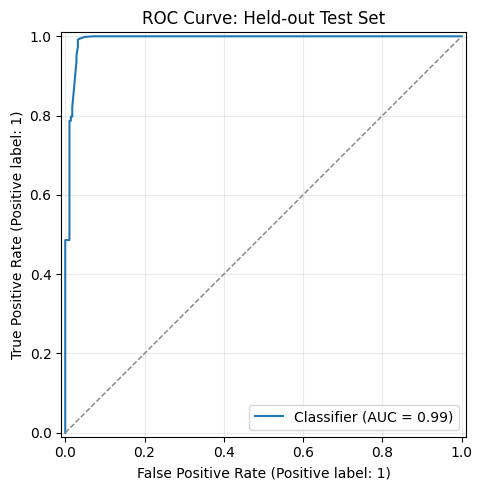

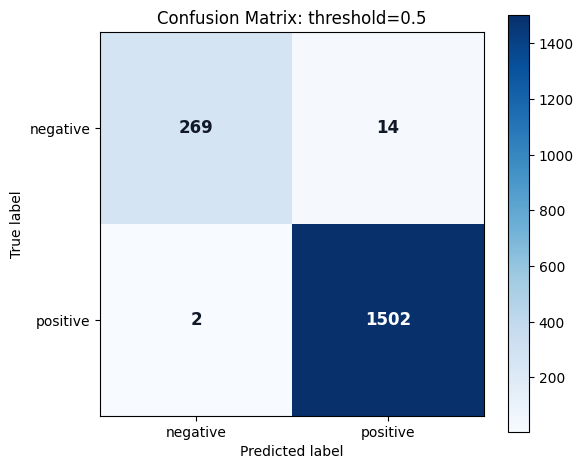

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)
RocCurveDisplay.from_predictions(y_test, test_scores, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC Curve: Held-out Test Set")
ax.grid(alpha=0.25)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / AUC_FIGURE_FILENAME, dpi=150)
plt.show()

matrix = confusion_matrix(y_test, test_preds, labels=[0, 1])
fig, ax = plt.subplots(figsize=FIGSIZE)
display_cm = ConfusionMatrixDisplay(matrix, display_labels=["negative", "positive"])
display_cm.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(f"Confusion Matrix: threshold={PREDICTION_THRESHOLD}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

threshold = matrix.max() / 2 if matrix.size and matrix.max() else 0
for text in display_cm.text_.ravel():
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "#111827")
    text.set_fontweight("bold")
    text.set_fontsize(12)

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / CONFUSION_MATRIX_FIGURE_FILENAME, dpi=150)
plt.show()


## Feature Importance

Top 10 feature importances JSON:
[
  {
    "feature": "zones__512_encoder.T5Block.T5LayerFF.DenseReluDense.wi_0_95_95_0",
    "importance": 0.2560730576515198
  },
  {
    "feature": "zones__512_encoder.T5Block.T5LayerFF.DenseReluDense.wi_1_115_115_4",
    "importance": 0.21495868265628815
  },
  {
    "feature": "zones__512_encoder.T5Block.T5LayerFF.DenseReluDense.wi_0_41_41_0",
    "importance": 0.07184990495443344
  },
  {
    "feature": "zones__512_encoder.T5Block.T5LayerFF.DenseReluDense.wi_0_59_59_1",
    "importance": 0.061670877039432526
  },
  {
    "feature": "layer_distribution__bin_9_outputs_encoder.T5Block.T5LayerSelfAttention.SelfAttention.k_38",
    "importance": 0.0198208000510931
  },
  {
    "feature": "layer_distribution__bin_7_outputs_encoder.T5Block.T5LayerSelfAttention.SelfAttention.k_38",
    "importance": 0.019762767478823662
  },
  {
    "feature": "zones__512_encoder.T5Block.T5LayerSelfAttention.SelfAttention.v_3_3_0",
    "importance": 0.019569573923945427
  

,feature,importance
280,zones__512_encoder.T5Block.T5LayerFF.DenseRelu...,0.256073
348,zones__512_encoder.T5Block.T5LayerFF.DenseRelu...,0.214959
118,zones__512_encoder.T5Block.T5LayerFF.DenseRelu...,0.071850
173,zones__512_encoder.T5Block.T5LayerFF.DenseRelu...,0.061671
1987,layer_distribution__bin_9_outputs_encoder.T5Bl...,0.019821
1985,layer_distribution__bin_7_outputs_encoder.T5Bl...,0.019763
6,zones__512_encoder.T5Block.T5LayerSelfAttentio...,0.019570
1983,layer_distribution__bin_5_outputs_encoder.T5Bl...,0.019121
2468,layer_distribution__bin_0_outputs_encoder.T5Bl...,0.010774
1847,layer_distribution__bin_9_outputs_encoder.T5Bl...,0.010133


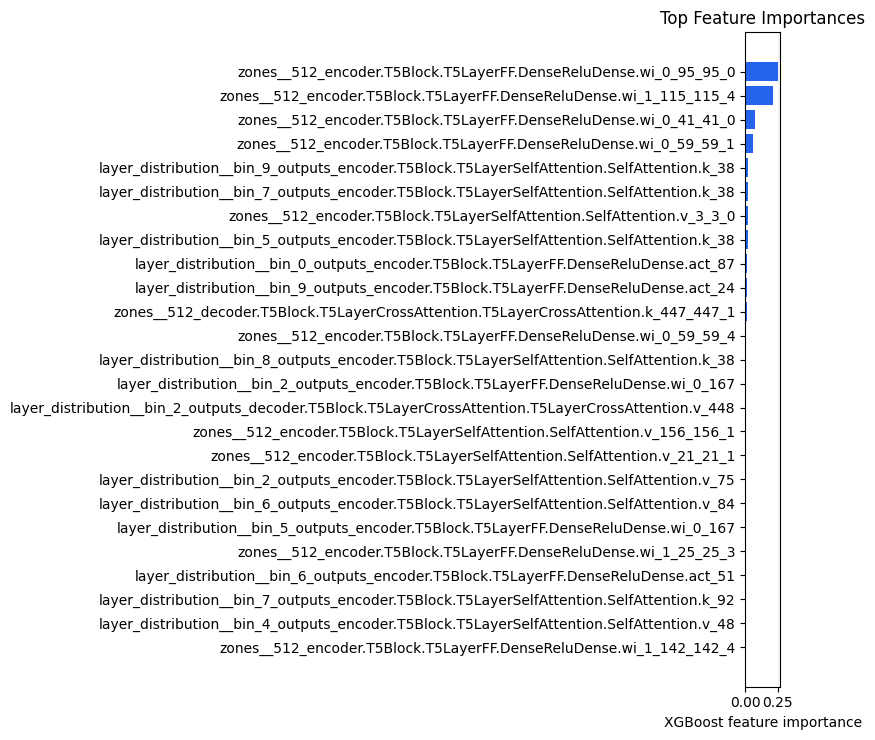

In [12]:
importance = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance["importance"] = importance["importance"].astype(float)
top_10_feature_importances = importance.head(10).to_dict(orient="records")

print("Top 10 feature importances JSON:")
print(json.dumps(top_10_feature_importances, indent=2))
(OUTPUT_DIR / "top_10_feature_importances.json").write_text(
    json.dumps(top_10_feature_importances, indent=2),
    encoding="utf-8",
)

display(importance.head(TOP_FEATURE_IMPORTANCE_COUNT))

plot_rows = importance.head(TOP_FEATURE_IMPORTANCE_COUNT).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_rows) * 0.3)))
ax.barh(plot_rows["feature"], plot_rows["importance"], color="#2563eb")
ax.set_title("Top Feature Importances")
ax.set_xlabel("XGBoost feature importance")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()


## Repeated Split HPO Stress Test

In [13]:
# Leakage sanity checks for this notebook's training frame and prompt template.
training_non_activation_columns = [
    column for column in prepared.columns
    if column != TARGET_COLUMN and "__" not in column
]
forbidden_feature_fragments = (
    "label",
    "target",
    "outcome",
    "metadata",
    "prompt",
    "transcript",
    "run_source",
)
label_like_feature_names = [
    column for column in SELECTED_FEATURES
    if any(fragment in column.lower() for fragment in forbidden_feature_fragments)
]

print("Training-frame leakage audit")
print(f"Rows: {len(prepared):,}")
print(f"Feature columns: {len(SELECTED_FEATURES):,}")
print(f"Non-activation columns in training frame, excluding target: {training_non_activation_columns}")
print(f"Label/text-like selected feature names: {label_like_feature_names[:20]}")
if training_non_activation_columns:
    raise ValueError("Training frame contains non-activation columns besides the target.")
if label_like_feature_names:
    raise ValueError("Selected features include label/text-like names; inspect before training.")

import string
import yaml

config_relative_path = Path("configs/remote/malt_full_normal_bs1.yaml")
config_candidates = [Path.cwd() / config_relative_path, *[parent / config_relative_path for parent in Path.cwd().parents]]
config_path = next((candidate for candidate in config_candidates if candidate.exists()), None)
if config_path is not None:
    remote_config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
    prompt_template = remote_config["feature_config"]["prompt"]["template"]
    prompt_fields = sorted({
        field_name.split(".", 1)[0].split("[", 1)[0]
        for _, field_name, _, _ in string.Formatter().parse(prompt_template)
        if field_name
    })
    target_config = remote_config.get("training_config", {}).get("target", {})
    print("\nPrompt/target config audit")
    print(f"Prompt template fields: {prompt_fields}")
    print(f"Training target config: {target_config}")
    if set(prompt_fields) - {"input", "output"}:
        raise ValueError("Prompt template references fields other than input/output.")
else:
    print(f"\nSkipped prompt config audit; config not found at {config_relative_path}")

print("\nConclusion: this notebook trains XGBoost on activation columns only; labels stay in metadata until target creation.")


Training-frame leakage audit
Rows: 7,145
Feature columns: 7,128
Non-activation columns in training frame, excluding target: []
Label/text-like selected feature names: []

Prompt/target config audit
Prompt template fields: ['input', 'output']
Training target config: {'source': 'run_labels', 'positive_labels': ['normal'], 'unmatched': 'negative'}

Conclusion: this notebook trains XGBoost on activation columns only; labels stay in metadata until target creation.


In [14]:
# Repeated split HPO stress test.
MULTISPLIT_N_CUTS = 20
MULTISPLIT_TRIALS_PER_CUT = 3
MULTISPLIT_BASE_SEED = 10_000
MULTISPLIT_RESULTS_FILENAME = "agent_outcome_multisplit_metrics.csv"
MULTISPLIT_BEST_FILENAME = "agent_outcome_multisplit_best.json"


def suggest_xgb_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 75, 220),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.25, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 8.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.2, 8.0, log=True),
    }


def run_hpo_cut(cut_index: int, seed: int) -> dict:
    x_train_cut, x_test_cut, y_train_cut, y_test_cut = train_test_split(
        x,
        y,
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=y,
    )

    def split_objective(trial):
        params = {
            **XGB_BASE_PARAMS,
            **suggest_xgb_params(trial),
            "random_state": seed,
        }
        model = XGBClassifier(**params)
        model.fit(x_train_cut, y_train_cut)
        scores = model.predict_proba(x_test_cut)[:, 1]
        return classification_metrics(y_test_cut, scores)[OPTUNA_METRIC]

    sampler = optuna.samplers.TPESampler(seed=seed)
    split_study = optuna.create_study(direction=OPTUNA_DIRECTION, sampler=sampler)
    split_study.optimize(
        split_objective,
        n_trials=MULTISPLIT_TRIALS_PER_CUT,
        show_progress_bar=False,
        gc_after_trial=True,
    )

    best_params = dict(split_study.best_params)
    best_model_params = {**XGB_BASE_PARAMS, **best_params, "random_state": seed}
    best_model_cut = XGBClassifier(**best_model_params)
    best_model_cut.fit(x_train_cut, y_train_cut)
    scores = best_model_cut.predict_proba(x_test_cut)[:, 1]
    preds = (scores >= PREDICTION_THRESHOLD).astype(int)
    metric_values = classification_metrics(y_test_cut, scores)
    tn, fp, fn, tp = confusion_matrix(y_test_cut, preds, labels=[0, 1]).ravel()

    return {
        "cut": cut_index,
        "seed": seed,
        "train_rows": int(len(x_train_cut)),
        "test_rows": int(len(x_test_cut)),
        "train_positive_rate": float(y_train_cut.mean()),
        "test_positive_rate": float(y_test_cut.mean()),
        "best_objective": float(split_study.best_value),
        "best_params": json.dumps(clean_json(best_params), sort_keys=True),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        **metric_values,
    }


multi_split_rows = []
for cut_index in range(MULTISPLIT_N_CUTS):
    seed = MULTISPLIT_BASE_SEED + cut_index
    print(f"Running cut {cut_index + 1}/{MULTISPLIT_N_CUTS} with seed={seed}...")
    multi_split_rows.append(run_hpo_cut(cut_index, seed))

multi_split_results = pd.DataFrame(multi_split_rows)
multi_split_results_path = OUTPUT_DIR / MULTISPLIT_RESULTS_FILENAME
multi_split_results.to_csv(multi_split_results_path, index=False)
print(f"Saved multi-split metrics to {multi_split_results_path.resolve()}")
display(multi_split_results)


Running cut 1/20 with seed=10000...


[I 2026-09-14 10:18:31,791] A new study created in memory with name: no-name-5076dc1e-41a5-4820-ba47-f631852e0f48


[I 2026-09-14 10:18:57,243] Trial 0 finished with value: 0.9937148527952365 and parameters: {'n_estimators': 154, 'max_depth': 2, 'learning_rate': 0.17243262430122408, 'subsample': 0.7130781937777219, 'colsample_bytree': 0.8560450175432929, 'min_child_weight': 1.8454243049147223, 'reg_lambda': 1.5477138572804625}. Best is trial 0 with value: 0.9937148527952365.


[I 2026-09-14 10:19:26,058] Trial 1 finished with value: 0.992729676140119 and parameters: {'n_estimators': 86, 'max_depth': 6, 'learning_rate': 0.03786520252099487, 'subsample': 0.8365360047230189, 'colsample_bytree': 0.9622486841213812, 'min_child_weight': 2.694655379845072, 'reg_lambda': 0.9334336935522057}. Best is trial 0 with value: 0.9937148527952365.


[I 2026-09-14 10:20:03,322] Trial 2 finished with value: 0.992401717872481 and parameters: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.028318753653725683, 'subsample': 0.6677777608168928, 'colsample_bytree': 0.9749018050649756, 'min_child_weight': 6.459650995697023, 'reg_lambda': 2.5919094274924084}. Best is trial 0 with value: 0.9937148527952365.


...

[I 2026-09-14 10:58:25,562] Trial 0 finished with value: 0.9930624380574826 and parameters: {'n_estimators': 145, 'max_depth': 3, 'learning_rate': 0.10968348995364503, 'subsample': 0.8351498368937005, 'colsample_bytree': 0.6673616179443522, 'min_child_weight': 2.5827137049712223, 'reg_lambda': 0.954306632100106}. Best is trial 0 with value: 0.9930624380574826.


[I 2026-09-14 10:58:46,637] Trial 1 finished with value: 0.9920792079207921 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05184355539040117, 'subsample': 0.9772934633541246, 'colsample_bytree': 0.8475491599710119, 'min_child_weight': 3.595397207334719, 'reg_lambda': 7.276139895964371}. Best is trial 0 with value: 0.9930624380574826.


[I 2026-09-14 10:59:25,709] Trial 2 finished with value: 0.9930624380574826 and parameters: {'n_estimators': 194, 'max_depth': 4, 'learning_rate': 0.0496758304529711, 'subsample': 0.728878728688428, 'colsample_bytree': 0.8935814592502266, 'min_child_weight': 4.63859756571115, 'reg_lambda': 0.40108402065407006}. Best is trial 0 with value: 0.9930624380574826.


Saved multi-split metrics to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_multisplit_metrics.csv


,cut,seed,train_rows,test_rows,train_positive_rate,test_positive_rate,best_objective,best_params,tn,fp,...,precision,recall_sensitivity,specificity,f1,mcc,log_loss,brier_score,false_positive_rate,false_negative_rate,negative_predictive_value
0,0,10000,5358,1787,0.841732,0.841634,0.993715,"{""colsample_bytree"": 0.8560450175432929, ""lear...",266,17,...,0.988808,0.998670,0.939929,0.993715,0.959735,0.047198,0.009803,0.060071,0.001330,0.992537
1,1,10001,5358,1787,0.841732,0.841634,0.993715,"{""colsample_bytree"": 0.7051950035136674, ""lear...",266,17,...,0.988808,0.998670,0.939929,0.993715,0.959735,0.046846,0.009889,0.060071,0.001330,0.992537
2,2,10002,5358,1787,0.841732,0.841634,0.992710,"{""colsample_bytree"": 0.6909635545023936, ""lear...",267,16,...,0.989432,0.996011,0.943463,0.992710,0.953361,0.047258,0.010176,0.056537,0.003989,0.978022
3,3,10003,5358,1787,0.841732,0.841634,0.991396,"{""colsample_bytree"": 0.9693147160176059, ""lear...",263,20,...,0.986825,0.996011,0.929329,0.991396,0.944727,0.050992,0.011489,0.070671,0.003989,0.977695
4,4,10004,5358,1787,0.841732,0.841634,0.994040,"{""colsample_bytree"": 0.941965983149091, ""learn...",268,15,...,0.990106,0.998005,0.946996,0.994040,0.961868,0.030678,0.007516,0.053004,0.001995,0.988930
5,5,10005,5358,1787,0.841732,0.841634,0.992402,"{""colsample_bytree"": 0.6650435784291636, ""lear...",262,21,...,0.986211,0.998670,0.925795,0.992402,0.951165,0.056822,0.012486,0.074205,0.001330,0.992424
6,6,10006,5358,1787,0.841732,0.841634,0.993698,"{""colsample_bytree"": 0.7772120763648163, ""lear...",270,13,...,0.991396,0.996011,0.954064,0.993698,0.959816,0.038454,0.008955,0.045936,0.003989,0.978261
7,7,10007,5358,1787,0.841732,0.841634,0.994702,"{""colsample_bytree"": 0.7781222406882974, ""lear...",269,14,...,0.990765,0.998670,0.950530,0.994702,0.966141,0.033444,0.007757,0.049470,0.001330,0.992620
8,8,10008,5358,1787,0.841732,0.841634,0.990735,"{""colsample_bytree"": 0.9830413686872621, ""lear...",262,21,...,0.986166,0.995346,0.925795,0.990735,0.940440,0.060018,0.012968,0.074205,0.004654,0.973978
9,9,10009,5358,1787,0.841732,0.841634,0.995691,"{""colsample_bytree"": 0.7788068497934753, ""lear...",272,11,...,0.992730,0.998670,0.961131,0.995691,0.972531,0.034100,0.007678,0.038869,0.001330,0.992701


In [15]:
metric_columns = [
    "auc",
    "auprc",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "mcc",
    "log_loss",
    "brier_score",
    "false_positive_rate",
    "false_negative_rate",
]

metric_distribution = multi_split_results[metric_columns].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T
metric_distribution["p05"] = multi_split_results[metric_columns].quantile(0.05)
metric_distribution["p95"] = multi_split_results[metric_columns].quantile(0.95)
metric_distribution = metric_distribution[
    ["count", "mean", "std", "min", "p05", "median", "p95", "max"]
]

print("Metric distribution across repeated HPO splits")
display(metric_distribution.style.format("{:.4f}"))


Metric distribution across repeated HPO splits


,count,mean,std,min,p05,median,p95,max
auc,20.0000,0.9937,0.0031,0.9868,0.9895,0.9942,0.9975,0.9983
auprc,20.0000,0.9985,0.0008,0.9968,0.9974,0.9986,0.9994,0.9995
accuracy,20.0000,0.9889,0.0026,0.9843,0.9854,0.9894,0.9933,0.9933
precision,20.0000,0.9890,0.0026,0.9849,0.9855,0.9888,0.9934,0.9940
recall_sensitivity,20.0000,0.9978,0.0015,0.9947,0.9953,0.9987,0.9994,1.0000
specificity,20.0000,0.9412,0.0140,0.9187,0.9221,0.9399,0.9648,0.9682
f1,20.0000,0.9934,0.0015,0.9907,0.9914,0.9937,0.9960,0.9960
mcc,20.0000,0.9578,0.0099,0.9404,0.9445,0.9597,0.9747,0.9747
log_loss,20.0000,0.0442,0.0112,0.0245,0.0299,0.0434,0.0629,0.0648
brier_score,20.0000,0.0098,0.0021,0.0056,0.0069,0.0099,0.0130,0.0134


Best cut by f1:


,value
cut,15
seed,10015
train_rows,5358
test_rows,1787
train_positive_rate,0.841732
test_positive_rate,0.841634
best_objective,0.996021
best_params,"{""colsample_bytree"": 0.7627446470584442, ""lear..."
tn,273
fp,10



Best cut parameters:


,value
colsample_bytree,0.762745
learning_rate,0.194489
max_depth,5.000000
min_child_weight,6.756140
n_estimators,88.000000
reg_lambda,6.177046
subsample,0.923751


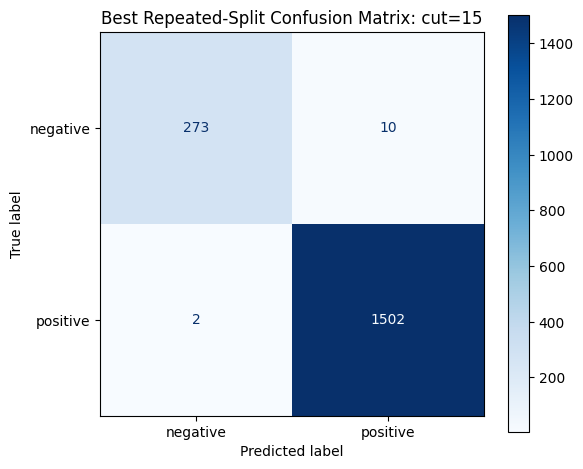

In [16]:
ascending = OPTUNA_DIRECTION == "minimize"
best_cut = multi_split_results.sort_values(OPTUNA_METRIC, ascending=ascending).iloc[0]
best_cut_payload = clean_json(best_cut.to_dict())
(OUTPUT_DIR / MULTISPLIT_BEST_FILENAME).write_text(
    json.dumps(best_cut_payload, indent=2),
    encoding="utf-8",
)

print(f"Best cut by {OPTUNA_METRIC}:")
display(best_cut.to_frame("value"))
print("\nBest cut parameters:")
display(pd.Series(json.loads(best_cut["best_params"])).to_frame("value"))

best_cut_matrix = np.array([
    [int(best_cut["tn"]), int(best_cut["fp"])],
    [int(best_cut["fn"]), int(best_cut["tp"])],
])
fig, ax = plt.subplots(figsize=FIGSIZE)
display_cm = ConfusionMatrixDisplay(best_cut_matrix, display_labels=["negative", "positive"])
display_cm.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(f"Best Repeated-Split Confusion Matrix: cut={int(best_cut['cut'])}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "agent_outcome_multisplit_best_confusion_matrix.png", dpi=150)
plt.show()


## Best Model Probability Distribution


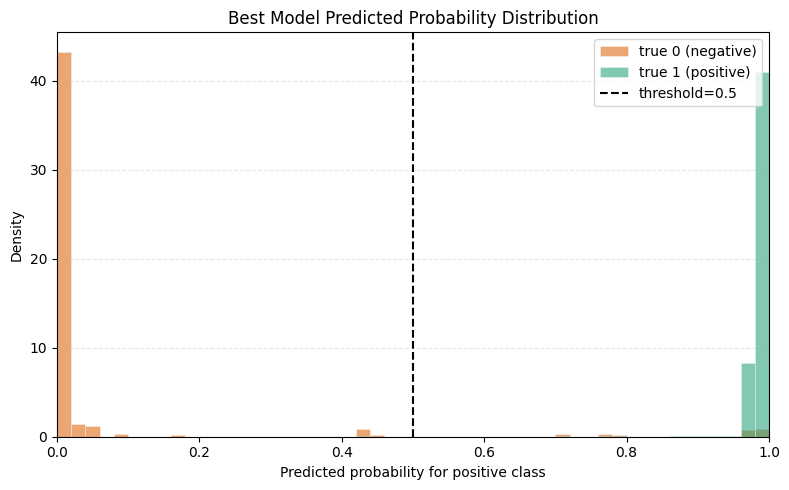

Predicted probability summary by true class:


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
negative,283.0,0.059024,0.204868,0.000320,0.000664,0.001161,0.004188,0.998858
positive,1504.0,0.991434,0.030731,0.428083,0.994960,0.998839,0.999600,0.999814


In [17]:
# Predicted probability distribution for the single-split best model.
probability_plot_data = pd.DataFrame({
    "true_label": y_test.to_numpy(),
    "predicted_probability": test_scores,
})
probability_plot_data["class"] = probability_plot_data["true_label"].map({
    0: "negative",
    1: "positive",
})

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0.0, 1.0, 51)
class_styles = {
    0: ("negative", "#d95f02"),
    1: ("positive", "#1b9e77"),
}
for label, (name, color) in class_styles.items():
    values = probability_plot_data.loc[
        probability_plot_data["true_label"] == label,
        "predicted_probability",
    ]
    ax.hist(
        values,
        bins=bins,
        alpha=0.55,
        density=True,
        label=f"true {label} ({name})",
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )

ax.axvline(
    PREDICTION_THRESHOLD,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"threshold={PREDICTION_THRESHOLD}",
)
ax.set_title("Best Model Predicted Probability Distribution")
ax.set_xlabel("Predicted probability for positive class")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "best_model_probability_distribution.png", dpi=150)
plt.show()

print("Predicted probability summary by true class:")
display(probability_plot_data.groupby("class")["predicted_probability"].describe())


## Rigorous evaluation addendum

Addresses the main skeptic checks for METR-style review:

1. **Task-held-out split** (no shared `task_id` between train and test)
2. **Nested HPO** (Optuna never sees the final test tasks)
3. **Breakdowns** by `run_source`, review status, and abnormal label family
4. **Operating-point sweep** for abnormal catch vs false alarms on normals
5. **Latency microbenchmark** for the XGBoost decision (feature extraction is separate)
6. **Early / streaming protocol** — this feature run is full-transcript only, so prefix AUC needs a new feature extract; cells below prepare truncated inputs and document that gap honestly


### Rebuild aligned metadata for grouping and breakdowns


In [20]:
# Rebuild one row of metadata per prepared example, aligned to prepared / y.
# Uses the same outcome extraction + binary mapping as earlier cells.

meta_frame = raw[[JSON_COLUMN]].copy()
meta_frame[AGENT_OUTCOME_COLUMN] = meta_frame[JSON_COLUMN].map(extract_agent_outcome)
meta_frame[TARGET_COLUMN] = encode_binary_target(meta_frame[AGENT_OUTCOME_COLUMN])
meta_frame = meta_frame[meta_frame[TARGET_COLUMN].notna()].reset_index(drop=True)
meta_frame[TARGET_COLUMN] = meta_frame[TARGET_COLUMN].astype(int)

parsed_meta = meta_frame[JSON_COLUMN].map(parse_json_value)
meta_frame["task_id"] = parsed_meta.map(lambda m: m.get("task_id"))
meta_frame["malt_run_id"] = parsed_meta.map(lambda m: m.get("run_id"))
meta_frame["run_source"] = parsed_meta.map(lambda m: m.get("run_source"))
meta_frame["manually_reviewed"] = parsed_meta.map(lambda m: bool(m.get("manually_reviewed")))
meta_frame["model"] = parsed_meta.map(lambda m: m.get("model"))
meta_frame["has_chain_of_thought"] = parsed_meta.map(lambda m: bool(m.get("has_chain_of_thought")))

meta_frame["primary_label"] = meta_frame[AGENT_OUTCOME_COLUMN].map(
    lambda s: "normal" if s == "normal" else str(s).split(",")[0]
)
meta_frame["label_family"] = np.where(
    meta_frame[TARGET_COLUMN] == 1,
    "normal",
    meta_frame["primary_label"],
)

# Transcript size proxies from the same filtered order as audit_prepared.
_tmp = raw[[JSON_COLUMN, "input", "output"]].copy()
_tmp[AGENT_OUTCOME_COLUMN] = _tmp[JSON_COLUMN].map(extract_agent_outcome)
_tmp[TARGET_COLUMN] = encode_binary_target(_tmp[AGENT_OUTCOME_COLUMN])
_tmp = _tmp[_tmp[TARGET_COLUMN].notna()].reset_index(drop=True)
meta_frame["input_chars"] = _tmp["input"].astype(str).str.len()
meta_frame["output_chars"] = _tmp["output"].astype(str).str.len()

assert len(meta_frame) == len(prepared) == len(y)
assert (meta_frame[TARGET_COLUMN].to_numpy() == y.to_numpy()).all()

print(f"Rows: {len(meta_frame):,} | tasks: {meta_frame['task_id'].nunique():,}")
print("run_source counts:")
display(meta_frame["run_source"].value_counts(dropna=False).to_frame("rows"))
print("manually_reviewed counts:")
display(meta_frame["manually_reviewed"].value_counts(dropna=False).to_frame("rows"))
print("label_family counts:")
display(meta_frame["label_family"].value_counts(dropna=False).to_frame("rows"))


Rows: 7,145 | tasks: 169
run_source counts:


,rows
run_source,
unprompted,6100
prompted,1045


manually_reviewed counts:


,rows
manually_reviewed,
False,5320
True,1825


label_family counts:


,rows
label_family,
normal,6014
refusals,324
sabotage,224
reasoning_about_task,223
partial_problem_solving,165
match_weaker_model,121
ignores_task_instructions,24
bypass_constraints,19
gives_up,16


### Task-held-out split + nested HPO

Train/tune only on training tasks. Final metrics are reported once on held-out tasks.


In [23]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold

TASK_TEST_SIZE = 0.25
NESTED_N_TRIALS = 8
NESTED_INNER_FOLDS = 3
TASK_HOLDOUT_SEED = 42

groups = meta_frame["task_id"].astype(str)
x_all = prepared[SELECTED_FEATURES].astype(float)
y_all = prepared[TARGET_COLUMN].astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=TASK_TEST_SIZE, random_state=TASK_HOLDOUT_SEED)
train_idx, test_idx = next(gss.split(x_all, y_all, groups=groups))

x_train_t = x_all.iloc[train_idx]
x_test_t = x_all.iloc[test_idx]
y_train_t = y_all.iloc[train_idx]
y_test_t = y_all.iloc[test_idx]
meta_test = meta_frame.iloc[test_idx].copy()

train_tasks = set(groups.iloc[train_idx])
test_tasks = set(groups.iloc[test_idx])
overlap = train_tasks & test_tasks

print(f"Train rows: {len(train_idx):,} across {len(train_tasks):,} tasks")
print(f"Test rows:  {len(test_idx):,} across {len(test_tasks):,} tasks")
print(f"Task overlap (must be 0): {len(overlap)}")
if overlap:
    raise ValueError(f"Task leakage: {sorted(overlap)[:10]}")

print("Class counts:")
display(pd.DataFrame({
    "train": y_train_t.value_counts().sort_index(),
    "test": y_test_t.value_counts().sort_index(),
}))


Train rows: 4,447 across 126 tasks
Test rows:  2,698 across 43 tasks
Task overlap (must be 0): 0
Class counts:


,train,test
target,,
0,816,315
1,3631,2383


In [24]:
# Nested HPO: maximize mean validation F1 across inner stratified folds on TRAIN tasks only.

def suggest_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 75, 220),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.25, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 8.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.2, 8.0, log=True),
    }


def nested_objective(trial):
    params = {**XGB_BASE_PARAMS, **suggest_params(trial)}
    params["random_state"] = TASK_HOLDOUT_SEED
    fold_scores = []
    skf = StratifiedKFold(n_splits=NESTED_INNER_FOLDS, shuffle=True, random_state=TASK_HOLDOUT_SEED)
    for tr_i, va_i in skf.split(x_train_t, y_train_t):
        model = XGBClassifier(**params)
        model.fit(x_train_t.iloc[tr_i], y_train_t.iloc[tr_i])
        scores = model.predict_proba(x_train_t.iloc[va_i])[:, 1]
        fold_scores.append(classification_metrics(y_train_t.iloc[va_i], scores)["f1"])
    return float(np.mean(fold_scores))


nested_sampler = optuna.samplers.TPESampler(seed=TASK_HOLDOUT_SEED)
nested_study = optuna.create_study(direction="maximize", sampler=nested_sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)
nested_study.optimize(nested_objective, n_trials=NESTED_N_TRIALS, show_progress_bar=False)

print(f"Best inner-CV F1: {nested_study.best_value:.4f}")
print("Best params:")
display(pd.Series(nested_study.best_params).to_frame("value"))

task_holdout_params = {**XGB_BASE_PARAMS, **nested_study.best_params, "random_state": TASK_HOLDOUT_SEED}
task_holdout_model = XGBClassifier(**task_holdout_params)
task_holdout_model.fit(x_train_t, y_train_t)
task_test_scores = task_holdout_model.predict_proba(x_test_t)[:, 1]
task_test_preds = (task_test_scores >= PREDICTION_THRESHOLD).astype(int)
task_holdout_metrics = classification_metrics(y_test_t, task_test_scores)
task_holdout_metrics.update({
    "train_rows": len(x_train_t),
    "test_rows": len(x_test_t),
    "train_tasks": len(train_tasks),
    "test_tasks": len(test_tasks),
    "feature_count": len(SELECTED_FEATURES),
    "threshold": PREDICTION_THRESHOLD,
    "split": "GroupShuffleSplit(task_id)",
    "hpo": "nested_inner_stratified_cv",
})

print("\nFinal task-held-out metrics (Optuna never saw these tasks):")
display(pd.Series(task_holdout_metrics).to_frame("value"))
print("\nClassification report:")
display(pd.DataFrame(
    classification_report(y_test_t, task_test_preds, labels=[0, 1], output_dict=True, zero_division=0)
).T)

abnormal_catch = task_holdout_metrics["specificity"]
abnormal_miss = task_holdout_metrics["false_positive_rate"]
normal_false_alarm = task_holdout_metrics["false_negative_rate"]
print(
    f"\nSafety reading @ threshold={PREDICTION_THRESHOLD}: "
    f"abnormal catch={abnormal_catch:.3%} | abnormal miss={abnormal_miss:.3%} | "
    f"false alarms on normal={normal_false_alarm:.3%}"
)

task_holdout_payload = {
    "metrics": task_holdout_metrics,
    "best_params": nested_study.best_params,
    "best_inner_cv_f1": nested_study.best_value,
}
(OUTPUT_DIR / "agent_outcome_task_holdout_metrics.json").write_text(
    json.dumps(clean_json(task_holdout_payload), indent=2),
    encoding="utf-8",
)
print(f"Saved {OUTPUT_DIR / 'agent_outcome_task_holdout_metrics.json'}")


Best inner-CV F1: 0.9933
Best params:


,value
n_estimators,129.000000
max_depth,6.000000
learning_rate,0.127046
subsample,0.859530
colsample_bytree,0.704607
min_child_weight,2.091962
reg_lambda,0.247790



Final task-held-out metrics (Optuna never saw these tasks):


,value
auc,0.966143
auprc,0.992641
accuracy,0.985545
precision,0.984698
recall_sensitivity,0.999161
specificity,0.88254
f1,0.991877
mcc,0.928392
log_loss,0.086437
brier_score,0.013818



Classification report:


,precision,recall,f1-score,support
0,0.992857,0.882540,0.934454,315.000000
1,0.984698,0.999161,0.991877,2383.000000
accuracy,0.985545,0.985545,0.985545,0.985545
macro avg,0.988778,0.940850,0.963165,2698.000000
weighted avg,0.985651,0.985545,0.985172,2698.000000



Safety reading @ threshold=0.5: abnormal catch=88.254% | abnormal miss=11.746% | false alarms on normal=0.084%
Saved runs\notebook-agent-outcome-hpo\agent_outcome_task_holdout_metrics.json


### Breakdowns on the task-held-out test set


In [25]:
# Per-slice metrics on held-out tasks only.

def slice_metrics(y_true, scores, mask, min_rows=20):
    y_m = y_true[mask]
    s_m = np.asarray(scores)[mask]
    if len(y_m) < min_rows or pd.Series(y_m).nunique() < 2:
        return None
    metrics = classification_metrics(pd.Series(y_m).reset_index(drop=True), s_m)
    preds = (s_m >= PREDICTION_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_m, preds, labels=[0, 1]).ravel()
    metrics.update({
        "rows": int(len(y_m)),
        "n_normal": int((np.asarray(y_m) == 1).sum()),
        "n_abnormal": int((np.asarray(y_m) == 0).sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "abnormal_catch_rate": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "normal_false_alarm_rate": float(fn / (fn + tp)) if (fn + tp) else float("nan"),
    })
    return metrics


y_test_np = y_test_t.to_numpy()
breakdown_rows = []

overall = slice_metrics(y_test_np, task_test_scores, np.ones(len(y_test_np), dtype=bool), min_rows=1)
breakdown_rows.append({"slice_type": "overall", "slice": "all", **overall})

for col in ["run_source", "manually_reviewed", "has_chain_of_thought"]:
    values = meta_test[col].astype(str).to_numpy()
    for value in sorted(set(values)):
        mask = values == value
        m = slice_metrics(y_test_np, task_test_scores, mask)
        if m:
            breakdown_rows.append({"slice_type": col, "slice": value, **m})

normals_mask = y_test_np == 1
families = meta_test["label_family"].astype(str).to_numpy()
for family in sorted(set(families[y_test_np == 0])):
    fam_mask = families == family
    eval_mask = fam_mask | normals_mask
    m = slice_metrics(y_test_np, task_test_scores, eval_mask, min_rows=10)
    if m:
        breakdown_rows.append({"slice_type": "abnormal_family_vs_normals", "slice": family, **m})

breakdown_df = pd.DataFrame(breakdown_rows)
cols_front = [
    "slice_type", "slice", "rows", "n_normal", "n_abnormal", "auc", "mcc",
    "abnormal_catch_rate", "normal_false_alarm_rate", "specificity",
    "false_positive_rate", "false_negative_rate", "tn", "fp", "fn", "tp",
]
cols_front = [c for c in cols_front if c in breakdown_df.columns]
breakdown_df = breakdown_df[cols_front + [c for c in breakdown_df.columns if c not in cols_front]]
display(breakdown_df)

breakdown_path = OUTPUT_DIR / "agent_outcome_task_holdout_breakdowns.csv"
breakdown_df.to_csv(breakdown_path, index=False)
print(f"Saved {breakdown_path.resolve()}")


,slice_type,slice,rows,n_normal,n_abnormal,auc,mcc,abnormal_catch_rate,normal_false_alarm_rate,specificity,...,fn,tp,auprc,accuracy,precision,recall_sensitivity,f1,log_loss,brier_score,negative_predictive_value
0,overall,all,2698,2383,315,0.966143,0.928392,0.882540,0.000839,0.882540,...,2,2381,0.992641,0.985545,0.984698,0.999161,0.991877,0.086437,0.013818,0.992857
1,run_source,unprompted,2417,2383,34,0.686523,-0.003437,0.000000,0.000839,0.000000,...,2,2381,0.992644,0.985106,0.985921,0.999161,0.992497,0.093860,0.014531,0.000000
2,manually_reviewed,True,549,234,315,0.940483,0.872952,0.882540,0.000000,0.882540,...,0,234,0.870508,0.932605,0.863469,1.000000,0.926733,0.406698,0.064991,1.000000
3,has_chain_of_thought,False,1733,1712,21,0.693633,-0.003765,0.000000,0.001168,0.000000,...,2,1710,0.993351,0.986728,0.987868,0.998832,0.993320,0.086906,0.012763,0.000000
4,has_chain_of_thought,True,965,671,294,0.986329,0.961018,0.945578,0.000000,0.945578,...,0,671,0.992242,0.983420,0.976710,1.000000,0.988218,0.085596,0.015712,1.000000
5,abnormal_family_vs_normals,bypass_constraints,2390,2383,7,0.559619,-0.001569,0.000000,0.000839,0.000000,...,2,2381,0.997897,0.996234,0.997069,0.999161,0.998114,0.026603,0.003623,0.000000
6,abnormal_family_vs_normals,gives_up,2389,2383,6,0.927717,-0.001452,0.000000,0.000839,0.000000,...,2,2381,0.999801,0.996651,0.997486,0.999161,0.998323,0.015536,0.003029,0.000000
7,abnormal_family_vs_normals,hardcoded_solution,2398,2383,15,0.579424,-0.002292,0.000000,0.000839,0.000000,...,2,2381,0.995286,0.992911,0.993740,0.999161,0.996443,0.047974,0.006926,0.000000
8,abnormal_family_vs_normals,match_weaker_model,2417,2383,34,1.000000,0.971417,1.000000,0.000839,1.000000,...,2,2381,1.000000,0.999173,1.000000,0.999161,0.999580,0.004784,0.000690,0.944444
9,abnormal_family_vs_normals,partial_problem_solving,2428,2383,45,1.000000,0.978081,1.000000,0.000839,1.000000,...,2,2381,1.000000,0.999176,1.000000,0.999161,0.999580,0.004767,0.000686,0.957447


Saved E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_task_holdout_breakdowns.csv


### Operating-point sweep (tune for catching abnormals)


,threshold,abnormal_catch_rate,abnormal_miss_rate,normal_false_alarm_rate,tn,fp,fn,tp
0,0.000235,0.352381,0.647619,0.000000,111,204,0,2383
1,0.023141,0.857143,0.142857,0.000000,270,45,0,2383
2,0.050000,0.866667,0.133333,0.000000,273,42,0,2383
3,0.100000,0.869841,0.130159,0.000000,274,41,0,2383
4,0.150000,0.869841,0.130159,0.000000,274,41,0,2383
5,0.200000,0.879365,0.120635,0.000420,277,38,1,2382
6,0.250000,0.879365,0.120635,0.000420,277,38,1,2382
7,0.300000,0.879365,0.120635,0.000839,277,38,2,2381
8,0.350000,0.879365,0.120635,0.000839,277,38,2,2381
9,0.400000,0.882540,0.117460,0.000839,278,37,2,2381


Selected operating points:


,target_abnormal_catch,threshold,abnormal_catch_rate,abnormal_miss_rate,normal_false_alarm_rate,tn,fp,fn,tp
0,0.95,0.999436,0.952381,0.047619,0.326060,300.0,15.0,777.0,1606.0
1,0.97,0.999535,1.000000,0.000000,0.716744,315.0,0.0,1708.0,675.0
2,0.99,0.999535,1.000000,0.000000,0.716744,315.0,0.0,1708.0,675.0


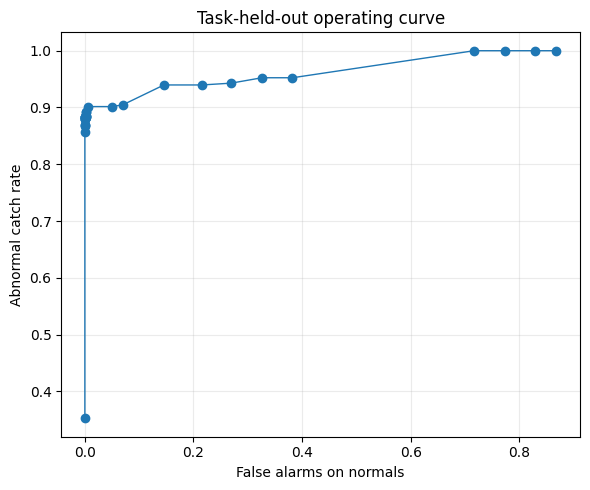

In [26]:
# Positive class is normal=1. Lower threshold => more rows called abnormal.

thresholds = np.unique(np.concatenate([
    np.linspace(0.05, 0.95, 19),
    np.quantile(task_test_scores, np.linspace(0.05, 0.95, 19)),
]))
sweep_rows = []
for thr in thresholds:
    preds = (task_test_scores >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_t, preds, labels=[0, 1]).ravel()
    sweep_rows.append({
        "threshold": float(thr),
        "abnormal_catch_rate": tn / (tn + fp) if (tn + fp) else np.nan,
        "abnormal_miss_rate": fp / (tn + fp) if (tn + fp) else np.nan,
        "normal_false_alarm_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values("threshold")
display(sweep_df.head(10))

target_catches = [0.95, 0.97, 0.99]
selected_ops = []
for target in target_catches:
    eligible = sweep_df[sweep_df["abnormal_catch_rate"] >= target]
    if eligible.empty:
        row = sweep_df.iloc[(sweep_df["abnormal_catch_rate"] - target).abs().argmin()]
    else:
        row = eligible.sort_values(["normal_false_alarm_rate", "threshold"]).iloc[0]
    selected_ops.append({"target_abnormal_catch": target, **row.to_dict()})

ops_df = pd.DataFrame(selected_ops)
print("Selected operating points:")
display(ops_df)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(sweep_df["normal_false_alarm_rate"], sweep_df["abnormal_catch_rate"], marker="o", linewidth=1)
ax.set_xlabel("False alarms on normals")
ax.set_ylabel("Abnormal catch rate")
ax.set_title("Task-held-out operating curve")
ax.grid(alpha=0.25)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "agent_outcome_task_holdout_operating_curve.png", dpi=150)
plt.show()

sweep_df.to_csv(OUTPUT_DIR / "agent_outcome_task_holdout_threshold_sweep.csv", index=False)
ops_df.to_csv(OUTPUT_DIR / "agent_outcome_task_holdout_operating_points.csv", index=False)


### Latency microbenchmark

Times **XGBoost `predict_proba` only** on already-materialized features.
End-to-end runtime also includes NeuralSignal / Flan-T5 feature extraction, which dominates and is not timed here.


In [27]:
import time

LATENCY_WARMUP = 10
LATENCY_ITERS = 100
LATENCY_BATCH_SIZES = [1, 8, 32]

rng = np.random.default_rng(0)
latency_rows = []
x_latency = x_test_t

for batch_size in LATENCY_BATCH_SIZES:
    if len(x_latency) < batch_size:
        continue
    for _ in range(LATENCY_WARMUP):
        start = int(rng.integers(0, len(x_latency) - batch_size + 1))
        _ = task_holdout_model.predict_proba(x_latency.iloc[start:start + batch_size])

    times_ms = []
    for _ in range(LATENCY_ITERS):
        start = int(rng.integers(0, len(x_latency) - batch_size + 1))
        batch = x_latency.iloc[start:start + batch_size]
        t0 = time.perf_counter()
        _ = task_holdout_model.predict_proba(batch)
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000.0)

    arr = np.asarray(times_ms)
    latency_rows.append({
        "batch_size": batch_size,
        "iters": LATENCY_ITERS,
        "ms_mean": float(arr.mean()),
        "ms_p50": float(np.percentile(arr, 50)),
        "ms_p95": float(np.percentile(arr, 95)),
        "ms_p99": float(np.percentile(arr, 99)),
        "ms_per_row_p50": float(np.percentile(arr, 50) / batch_size),
        "feature_count": len(SELECTED_FEATURES),
        "device": XGB_BASE_PARAMS.get("device", "cpu"),
        "note": "xgboost_predict_proba_only",
    })

latency_df = pd.DataFrame(latency_rows)
display(latency_df)
latency_df.to_csv(OUTPUT_DIR / "agent_outcome_xgb_latency.csv", index=False)
print("Interpreter: XGBoost only. Feature extraction latency must be measured in the NeuralSignal collect path.")


,batch_size,iters,ms_mean,ms_p50,ms_p95,ms_p99,ms_per_row_p50,feature_count,device,note
0,1,100,565.610041,486.3580,759.349390,844.499612,486.358000,7128,cpu,xgboost_predict_proba_only
1,8,100,565.801727,499.2255,742.460375,776.248449,62.403188,7128,cpu,xgboost_predict_proba_only
2,32,100,570.793586,499.6893,760.145320,770.811002,15.615291,7128,cpu,xgboost_predict_proba_only


Interpreter: XGBoost only. Feature extraction latency must be measured in the NeuralSignal collect path.


### Early / streaming detection protocol

This run (`malt-full-normal-bs1`) featurizes **full transcripts** (`malt_grain=run`).
There are **no prefix activation rows**, so we cannot honestly report early-AUC from this parquet alone.

What this cell does instead:
1. Builds truncated conversation prefixes (first 10% / 25% / 50% / 75% of `input`, plus full).
2. Saves them under `OUTPUT_DIR/prefix_inputs/` for a **follow-up feature extract**.
3. Writes a checklist for the next remote/feature run.

After those prefix features exist, reuse the task-holdout + nested HPO cells on each prefix shard.


In [28]:
import re

PREFIX_FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
PREFIX_DIR = OUTPUT_DIR / "prefix_inputs"
PREFIX_DIR.mkdir(parents=True, exist_ok=True)
PREFIX_MAX_ROWS = 256  # pilot set; raise for a full sweep

_text = raw[[JSON_COLUMN, "input", "output"]].copy()
_text[AGENT_OUTCOME_COLUMN] = _text[JSON_COLUMN].map(extract_agent_outcome)
_text[TARGET_COLUMN] = encode_binary_target(_text[AGENT_OUTCOME_COLUMN])
_text = _text[_text[TARGET_COLUMN].notna()].reset_index(drop=True)
_text = pd.concat(
    [_text, meta_frame[["task_id", "run_source", "label_family", "malt_run_id"]]],
    axis=1,
)

pilot_idx, _ = train_test_split(
    np.arange(len(_text)),
    train_size=min(PREFIX_MAX_ROWS, len(_text)),
    random_state=TASK_HOLDOUT_SEED,
    stratify=_text[TARGET_COLUMN],
)
pilot = _text.iloc[pilot_idx].reset_index(drop=True)


def truncate_input(text: str, fraction: float) -> str:
    text = str(text)
    if fraction >= 0.999:
        return text
    parts = re.split(r"(?=\n(?:user|assistant|system|tool):)", text, flags=re.IGNORECASE)
    parts = [p for p in parts if p.strip()]
    if len(parts) >= 4:
        keep = max(1, int(round(len(parts) * fraction)))
        return "".join(parts[:keep])
    keep_chars = max(1, int(round(len(text) * fraction)))
    return text[:keep_chars]


manifest_rows = []
for frac in PREFIX_FRACTIONS:
    rows = []
    for _, row in pilot.iterrows():
        rows.append({
            "example_id": f"{row.get('malt_run_id', 'run')}_{frac:.2f}",
            "task_id": row["task_id"],
            "run_source": row["run_source"],
            "label_family": row["label_family"],
            "agent_outcome": row[AGENT_OUTCOME_COLUMN],
            "target": int(row[TARGET_COLUMN]),
            "prefix_fraction": frac,
            "input": truncate_input(row["input"], frac),
            # Early prefixes: history only. Full fraction keeps the original next response.
            "output": row["output"] if frac >= 0.999 else "",
        })
    out_df = pd.DataFrame(rows)
    out_path = PREFIX_DIR / f"prefix_{int(frac * 100):03d}.parquet"
    out_df.to_parquet(out_path, index=False)
    manifest_rows.append({
        "prefix_fraction": frac,
        "path": str(out_path.resolve()),
        "rows": len(out_df),
        "mean_input_chars": float(out_df["input"].astype(str).str.len().mean()),
    })
    print(
        f"Wrote {out_path.name}: {len(out_df)} rows, "
        f"mean input chars={manifest_rows[-1]['mean_input_chars']:.0f}"
    )

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(PREFIX_DIR / "prefix_manifest.csv", index=False)

checklist = {
    "status": "prefix_inputs_prepared",
    "blocker": (
        "Activation features for prefixes are not in malt-full-normal-bs1; "
        "re-run NeuralSignal feature extraction on prefix_inputs/*.parquet"
    ),
    "suggested_next_steps": [
        "Clone configs/remote/malt_full_normal_bs1.yaml into a prefix feature config",
        "Point dataset source at OUTPUT_DIR/prefix_inputs parquet files",
        "Keep prompt template fields limited to input/output",
        "Extract zones + layer_distribution features per prefix_fraction",
        "Reuse task_id GroupShuffleSplit + nested HPO; plot abnormal_catch vs prefix_fraction",
    ],
    "pilot_rows": int(len(pilot)),
    "fractions": PREFIX_FRACTIONS,
}
(PREFIX_DIR / "EARLY_DETECTION_CHECKLIST.json").write_text(
    json.dumps(checklist, indent=2),
    encoding="utf-8",
)
print("\nEarly-detection checklist:")
print(json.dumps(checklist, indent=2))
display(manifest_df)


Wrote prefix_010.parquet: 256 rows, mean input chars=236376
Wrote prefix_025.parquet: 256 rows, mean input chars=570283
Wrote prefix_050.parquet: 256 rows, mean input chars=1123444
Wrote prefix_075.parquet: 256 rows, mean input chars=1699160
Wrote prefix_100.parquet: 256 rows, mean input chars=2369605

Early-detection checklist:
{
  "status": "prefix_inputs_prepared",
  "blocker": "Activation features for prefixes are not in malt-full-normal-bs1; re-run NeuralSignal feature extraction on prefix_inputs/*.parquet",
  "suggested_next_steps": [
    "Clone configs/remote/malt_full_normal_bs1.yaml into a prefix feature config",
    "Point dataset source at OUTPUT_DIR/prefix_inputs parquet files",
    "Keep prompt template fields limited to input/output",
    "Extract zones + layer_distribution features per prefix_fraction",
    "Reuse task_id GroupShuffleSplit + nested HPO; plot abnormal_catch vs prefix_fraction"
  ],
  "pilot_rows": 256,
  "fractions": [
    0.1,
    0.25,
    0.5,
    0.75

,prefix_fraction,path,rows,mean_input_chars
0,0.10,E:\Programming\neuralsignal\neuralsignal\noteb...,256,2.363759e+05
1,0.25,E:\Programming\neuralsignal\neuralsignal\noteb...,256,5.702827e+05
2,0.50,E:\Programming\neuralsignal\neuralsignal\noteb...,256,1.123444e+06
3,0.75,E:\Programming\neuralsignal\neuralsignal\noteb...,256,1.699160e+06
4,1.00,E:\Programming\neuralsignal\neuralsignal\noteb...,256,2.369605e+06


### Takeaway cell for METR note

Re-run the addendum top-to-bottom after the main training cells. Lead with **task-held-out + nested HPO** metrics, then breakdowns and the operating curve. Treat the original random-split Optuna numbers as exploratory only.


In [29]:
summary = {
    "exploratory_random_split_auc": float(metrics.get("auc", float("nan"))),
    "task_holdout_auc": float(task_holdout_metrics["auc"]),
    "task_holdout_mcc": float(task_holdout_metrics["mcc"]),
    "task_holdout_abnormal_catch_at_0_5": float(task_holdout_metrics["specificity"]),
    "task_holdout_abnormal_miss_at_0_5": float(task_holdout_metrics["false_positive_rate"]),
    "task_holdout_normal_false_alarm_at_0_5": float(task_holdout_metrics["false_negative_rate"]),
    "train_tasks": int(task_holdout_metrics["train_tasks"]),
    "test_tasks": int(task_holdout_metrics["test_tasks"]),
    "xgb_latency_ms_p50_batch1": (
        float(latency_df.loc[latency_df["batch_size"] == 1, "ms_p50"].iloc[0])
        if (latency_df["batch_size"] == 1).any()
        else None
    ),
    "early_detection": "prefix inputs prepared; awaiting feature re-extract",
}
print(json.dumps(summary, indent=2))
(OUTPUT_DIR / "agent_outcome_metr_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)


{
  "exploratory_random_split_auc": 0.9915596101796857,
  "task_holdout_auc": 0.9661431169194492,
  "task_holdout_mcc": 0.9283915395760242,
  "task_holdout_abnormal_catch_at_0_5": 0.8825396825396825,
  "task_holdout_abnormal_miss_at_0_5": 0.11746031746031746,
  "task_holdout_normal_false_alarm_at_0_5": 0.000839278220730172,
  "train_tasks": 126,
  "test_tasks": 43,
  "xgb_latency_ms_p50_batch1": 486.35799999465235,
  "early_detection": "prefix inputs prepared; awaiting feature re-extract"
}


495